In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Concrete Strength for Regression

In [2]:
columns = ['Cement', 'Blast Furnance Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Concrete compressive strength']
df = pd.read_csv('Concrete_Data.csv', names=columns, header=0)
df.head()

,Cement,Blast Furnance Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [ ]:
#visualizing the dataset

for label in columns[:-1]:
    plt.scatter(df[label], df['Concrete compressive strength'])
    plt.title(label)
    plt.xlabel(label)
    plt.ylabel('Concrete Strength')
    plt.show()

In [4]:
train, val, test = np.split(df.sample(frac=1), [int(len(df)*0.6), int(len(df)*0.8)])


c:\Users\syedm\OneDrive\Desktop\ML_Training\Freecodecamp\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [6]:
def get_x_y(df):
    x = df[[c for c in df.columns if c!='Concrete compressive strength'] ]
    y = df['Concrete compressive strength']
    return x,y

In [10]:
x_train, y_train = get_x_y(train)
x_val, y_val = get_x_y(val)


##### Without Feature Scaling


In [9]:
rg_model = LinearRegression()
rg_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
rg_model.score(x_val, y_val)

0.5696154565184238

##### With Feature Scaling


In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.fit_transform(x_val)

In [14]:
scaled_rg = LinearRegression()
scaled_rg.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
scaled_rg.score(x_val_scaled, y_val)

0.5670579496659898



# Using Neural Network

In [16]:
import tensorflow as tf

In [29]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.show()

In [25]:
normalizer = tf.keras.layers.Normalization(input_shape = (8,), axis=-1)
normalizer.adapt(x_train.to_numpy())

c:\Users\syedm\OneDrive\Desktop\ML_Training\Freecodecamp\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
neural_net = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])
neural_net.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

In [28]:
history = neural_net.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    verbose=0, epochs=100 
)

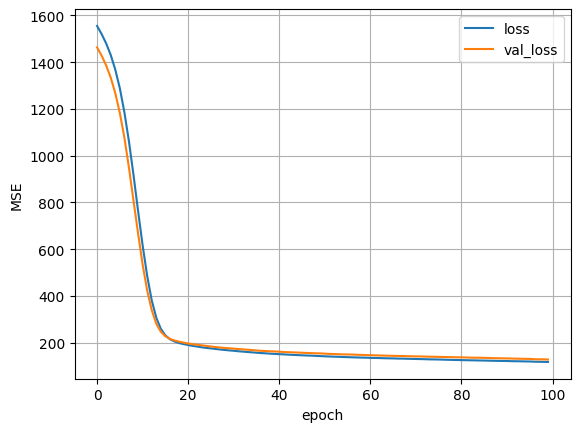

In [30]:
plot_loss(history)


# comparision

In [31]:
x_test, y_test = get_x_y(test)

In [32]:
rg_y_pred = rg_model.predict(x_test)
nn_y_pred = neural_net.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


[]

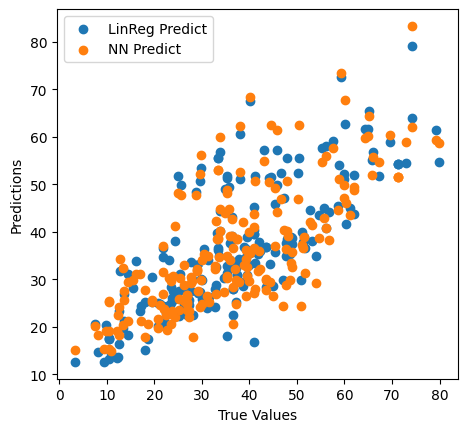

In [33]:
ax = plt.axes(aspect='equal')
plt.scatter(y_test, rg_y_pred, label='LinReg Predict')
plt.scatter(y_test, nn_y_pred, label='NN Predict')
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.legend()
plt.plot(c='red')